In [2]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

### PyPSA Technology Database

In [3]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

- all costs are annualised

In [4]:
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

### Weather Data

In [5]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

In [6]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
print(PV_data.head())

                     DK01  DK02  DK03  DK04  DK05
time                                             
1980-01-01 00:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 01:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 02:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 03:00:00   0.0   0.0   0.0   0.0   0.0
1980-01-01 04:00:00   0.0   0.0   0.0   0.0   0.0


<Axes: xlabel='time'>

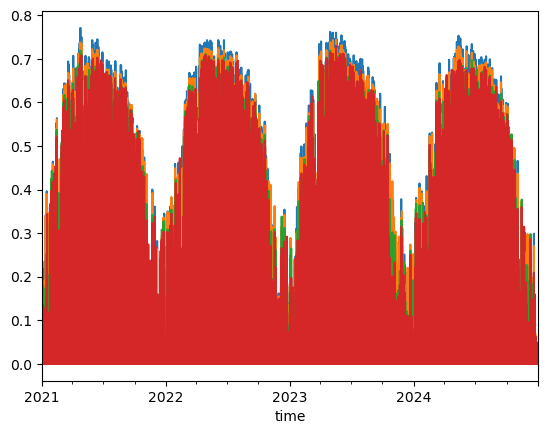

In [40]:
PV_data["DK01"]["2021":"2024"].plot()
PV_data["DK02"]["2021":"2024"].plot()
PV_data["DK03"]["2021":"2024"].plot()
PV_data["DK04"]["2021":"2024"].plot()

In [41]:
CF_solar = PV_data.mean(axis = 1) # average all the years

<Axes: xlabel='time'>

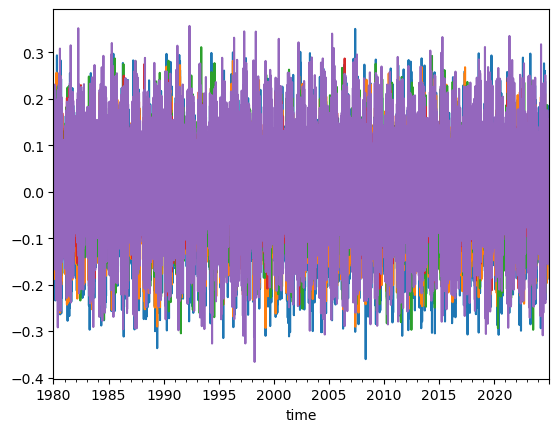

In [48]:
(CF_solar - PV_data["DK01"]).plot()
(CF_solar - PV_data["DK02"]).plot()
(CF_solar - PV_data["DK03"]).plot()
(CF_solar - PV_data["DK04"]).plot()
(CF_solar - PV_data["DK05"]).plot()

In [7]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()

print(OnshoreWind_Data.head())

                     NATIONAL      DK01      DK02      DK03      DK04  \
time                                                                    
1980-01-01 00:00:00  0.100020  0.169258  0.154797  0.058525  0.082945   
1980-01-01 01:00:00  0.095627  0.157692  0.155743  0.059855  0.076598   
1980-01-01 02:00:00  0.090815  0.145822  0.156026  0.060255  0.070185   
1980-01-01 03:00:00  0.082520  0.134984  0.153629  0.058150  0.058770   
1980-01-01 04:00:00  0.071892  0.122622  0.150896  0.054550  0.042691   

                         DK05  
time                           
1980-01-01 00:00:00  0.120442  
1980-01-01 01:00:00  0.112279  
1980-01-01 02:00:00  0.103703  
1980-01-01 03:00:00  0.092318  
1980-01-01 04:00:00  0.080078  


In [20]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

<Axes: xlabel='time'>

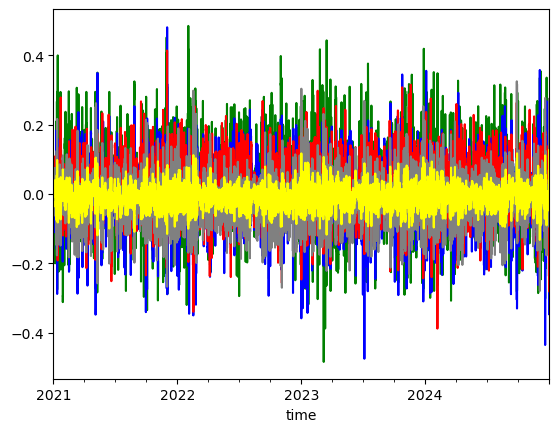

In [35]:
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK01"]["2021":"2024"]).plot(color = "green")
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK02"]["2021":"2024"]).plot(color = "blue")
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK03"]["2021":"2024"]).plot(color = "red")
(CF_wind["2021":"2024"] - OnshoreWind_Data["DK04"]["2021":"2024"]).plot(color = "grey")
(CF_wind["2021":"2024"] - OnshoreWind_Data["NATIONAL"]["2021":"2024"]).plot(color = "yellow")

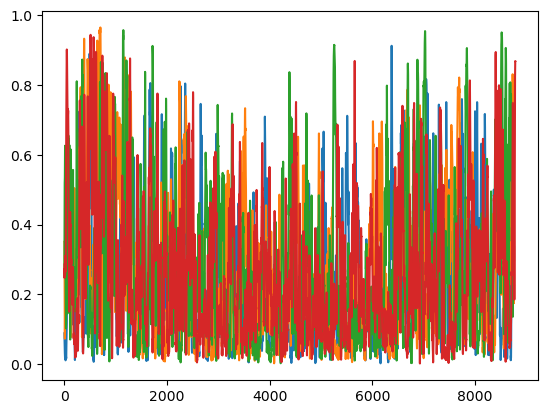

In [55]:
plt.plot(CF_wind["2021"].values)
plt.plot(CF_wind["2022"].values)
plt.plot(CF_wind["2023"].values)
plt.plot(CF_wind["2024"].values)
plt.show()

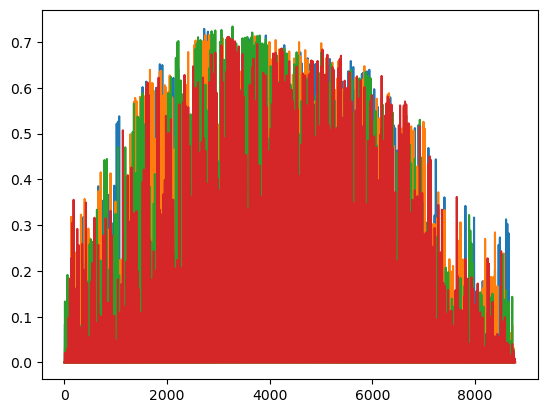

In [56]:
plt.plot(CF_solar["2021"].values)
plt.plot(CF_solar["2022"].values)
plt.plot(CF_solar["2023"].values)
plt.plot(CF_solar["2024"].values)
plt.show()

### Natural Gas Prices